In [16]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [17]:
seed = 2724

### Import data

In [18]:
url = "https://raw.githubusercontent.com/asripathi1809/cse_3000/refs/heads/main/mod04_data/sample.csv"
df = pd.read_csv(url)

### Separate data by independent (X) and dependent (y) variables

In [19]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [21]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [22]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 1490/1500 [02:02<00:00]       

This will allow us to see which variables are most important to predicting the outcome.

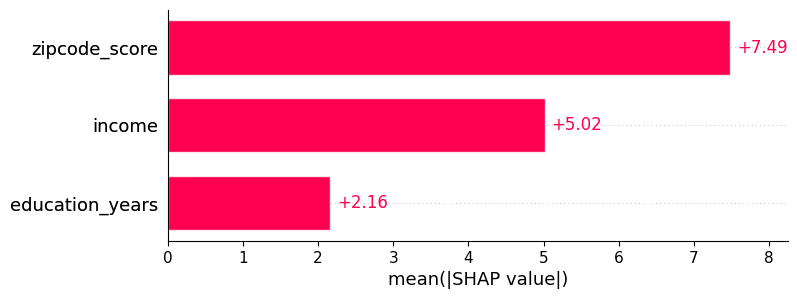

In [23]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [24]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [25]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

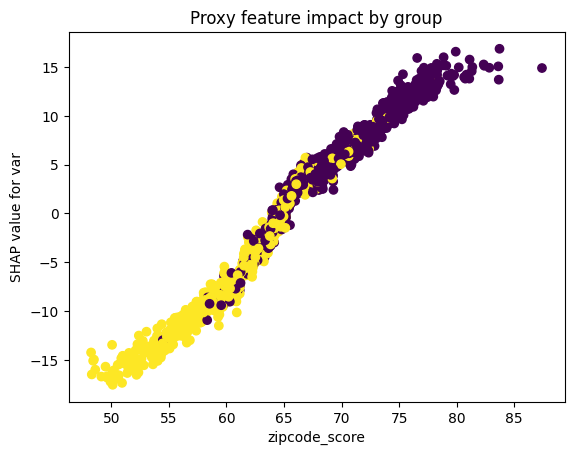

In [26]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value?

SHAP values are helping with quantifying the contribution of each feature to a model's prediction for a given observation. A positive SHAP value means that the feature pushes prediction higher, and a negative SHAP value means that feature pushes preduction lower.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

My answer would be "No, the variable group was not used in my model" because it was not used as an input, and it is not necessarily free from bias since the other variables could be proxies.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

My answer will be "yes, the model outcome is correlated with group". Even though group was not used directly, other features may be correlated with group.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

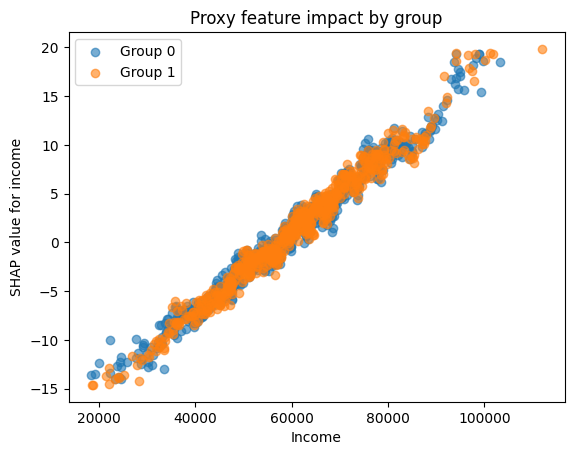

In [30]:
import matplotlib.pyplot as plt
import numpy as np

income_idx = X_test_with_group.columns.get_loc("income")

income_shap = shap_values.values[:, income_idx]

income_values = X_test_with_group["income"].values

groups = df.loc[X_test_with_group.index, "group"].values

plt.figure()
for i in np.unique(groups):
  mask = (groups == i)
  plt.scatter(income_values[mask], income_shap[mask], label = f"Group {i}", alpha = 0.6)

plt.xlabel("Income")
plt.ylabel("SHAP value for income")
plt.title("Proxy feature impact by group")
plt.legend()
plt.show()

The proxy feature for income shows how SHAP contribution of income differs across many groups. The plot for zipcode_score is different because this one shows a more gradual relationship and stronger clustering between groups.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

1. Did you check whether other features act as proxies for group?
2. How stable are SHAP explanations across different model retrainings?